# Verdant Inlet Velocity Profile Analysis
This notebook loads flood and ebb profile datasets extracted from CFD inlets, visualizes normalized vertical velocity profiles, and fits two common profile models:

- Logarithmic wall law: $W = \frac{1}{\kappa}\ln(y) + B$
- Power law: $W = a y^b$

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Piecewise Profile Visualization
Visualize the specified piecewise velocity profile:
- if `r <= 0.001746`, `u = 1e-8`
- if `0.001746 < r <= 0.02237`, `u = 0.2389*log(r) + 1.5128`
- if `0.02237 < r <= 0.8`, `u = 0.1408*log(r) + 1.1592`
- if `r > 0.8`, `u = 0.1408*log(0.8) + 1.1592`

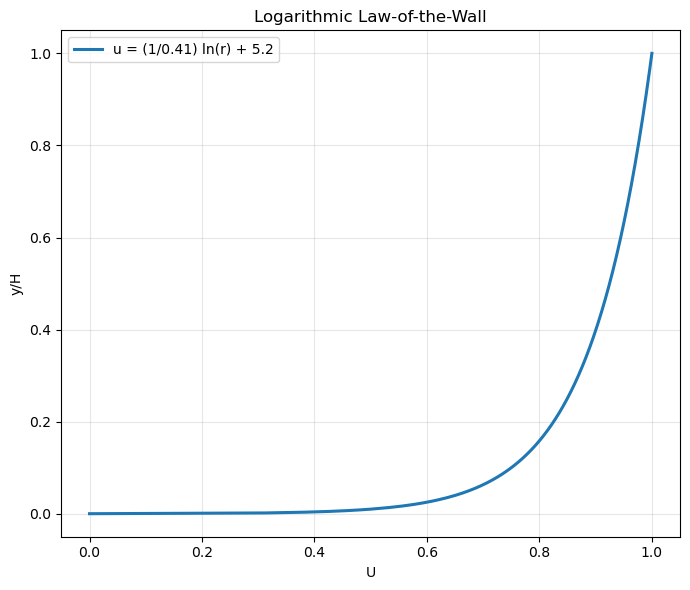

In [17]:
# Logarithmic law of the wall profile: u = (1/kappa) * ln(r) + B
kappa = 0.41
B = 5.2

# r is a dimensionless wall-normal coordinate
r = np.linspace(0.0001, 1, 600)
u = (1.0 / kappa) * np.log(r) + B

# Normalize u from 0 to 1
u_min = u.min()
u_max = u.max()
u_norm = (u - u_min) / (u_max - u_min)

plt.figure(figsize=(7, 6))
plt.plot(u_norm, r, linewidth=2.2, color='tab:blue', label=f'u = (1/{kappa}) ln(r) + {B}')

# Optional reference levels
for y in [0.001, 0.01, 0.1, 1.0]:
    x = (1.0 / kappa) * np.log(y) + B
    x_norm = (x - u_min) / (u_max - u_min)
    #plt.scatter([x_norm], [y], color='tab:red', s=24, zorder=3)
plt.xlabel('U')
plt.ylabel('y/H')
plt.title('Logarithmic Law-of-the-Wall')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()